## NB1 - Data Cleaning and EDA
### Goal

# (1) Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# (2) Load Dataset

In [3]:
df = pd.read_excel("C:/Projects/08_Customer_Intellignece_System/data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# (3) Data quick check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# (4) Data Cleaning

In [7]:
# 1. Remove missing customerID
df = df.dropna(subset=['CustomerID'])

In [8]:
# 2. remove cancelled transactions (Cancelled invoices start with C)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
# 3. Remove negative or zero quantity
df = df[df['Quantity'] > 0]

In [10]:
# 4. Remove negative or zero price
df = df[df['UnitPrice'] > 0]

In [11]:
# 5. Remove missing values
df = df.dropna(subset=['Description'])

# (5) Create Total Price

In [12]:
df['Total_Price'] = df['Quantity'] * df['UnitPrice']

# (6) Convert Date

In [13]:
df['Invoice_Date'] = pd.to_datetime(df['InvoiceDate'])

# (7) Quick EDA

In [ ]:
# Top Countries
df['Country'].value_counts().head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

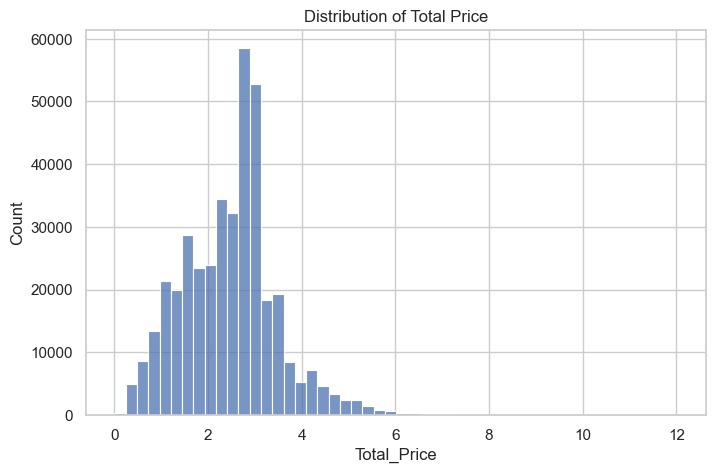

In [16]:
# Sales distribution
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['Total_Price']), bins=50)
plt.title("Distribution of Total Price")
plt.show()

# (8) Save the cleaned dataset

In [18]:
df.to_csv("C:/Projects/08_Customer_Intellignece_System/data/Cleaned_dataset.csv", index=False)